# RNN 算法原理与实现详解 (NumPy + SGD)

本文档详细介绍了循环神经网络 (RNN) 算法原理。该实现完全基于 NumPy，手动完成了前向传播、反向传播 (BPTT) 以及随机梯度下降 (SGD) 优化过程。

## 1. 核心数学模型

### 1.1 符号定义
*   $x_t \in \mathbb{R}^{D_{in}}$: 时间步 $t$ 的输入向量。
*   $h_t \in \mathbb{R}^{D_{hidden}}$: 时间步 $t$ 的隐藏状态 (Hidden State)。
*   $y \in \mathbb{R}^{D_{out}}$: 最终输出向量 (预测值)。
*   $W_{xh} \in \mathbb{R}^{D_{in} \times D_{hidden}}$: 输入层到隐藏层的权重矩阵。
*   $W_{hh} \in \mathbb{R}^{D_{hidden} \times D_{hidden}}$: 隐藏层到隐藏层的权重矩阵 (循环权重)。
*   $W_{hy} \in \mathbb{R}^{D_{hidden} \times D_{out}}$: 隐藏层到输出层的权重矩阵。
*   $b_h \in \mathbb{R}^{D_{hidden}}$: 隐藏层偏置。
*   $b_y \in \mathbb{R}^{D_{out}}$: 输出层偏置。

### 1.2 前向传播 (Forward Propagation)
对于长度为 $T$ 的输入序列 $x_1, x_2, ..., x_T$：

**Step 1: 循环更新隐藏状态**
对于每个时间步 $t = 1$ 到 $T$：
$$
h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h)
$$
*(注：$h_0$ 通常初始化为全零向量)*

**Step 2: 计算最终输出**
使用最后一个时间步的隐藏状态 $h_T$ 进行预测：
$$
y_{pred} = h_T W_{hy} + b_y
$$

### 1.3 损失函数 (Loss Function)
使用均方误差 (MSE) 衡量预测值与真实值 $y_{true}$ 之间的差距：
$$
L = \frac{1}{2N} \sum_{i=1}^{N} ||y_{pred}^{(i)} - y_{true}^{(i)}||^2
$$

### 1.4 反向传播 (BPTT - Backpropagation Through Time)
我们需要计算损失函数 $L$ 对所有参数的梯度。由于 RNN 存在时间依赖，梯度需要沿时间轴反向传播。

**1. 输出层梯度**
$$
\frac{\partial L}{\partial y_{pred}} = \frac{1}{N} (y_{pred} - y_{true})
$$
$$
\frac{\partial L}{\partial W_{hy}} = h_T^T (\frac{\partial L}{\partial y_{pred}})
$$
$$
\frac{\partial L}{\partial b_y} = \sum (\frac{\partial L}{\partial y_{pred}})
$$

**2. 隐藏层梯度 (时间反向传播)**
令 $dh_t = \frac{\partial L}{\partial h_t}$。
对于最后一个时间步 $T$：
$$
dh_T = (\frac{\partial L}{\partial y_{pred}}) W_{hy}^T
$$

对于之前的每一个时间步 $t = T, T-1, ..., 1$：
首先计算经过激活函数之前的梯度 $dh_{raw}$ (因为 $h_t = \tanh(h_{raw})$)：
$$
dh_{raw} = dh_t \odot (1 - h_t^2)
$$
*(注：$\odot$ 表示逐元素相乘，$(1 - h_t^2)$ 是 tanh 的导数)*

然后累加梯度：
$$
\frac{\partial L}{\partial W_{hh}} \leftarrow \frac{\partial L}{\partial W_{hh}} + h_{t-1}^T dh_{raw}
$$
$$
\frac{\partial L}{\partial W_{xh}} \leftarrow \frac{\partial L}{\partial W_{xh}} + x_t^T dh_{raw}
$$
$$
\frac{\partial L}{\partial b_h} \leftarrow \frac{\partial L}{\partial b_h} + \sum dh_{raw}
$$

最后计算传递给上一时刻的梯度 $dh_{t-1}$：
$$
dh_{t-1} = dh_{raw} W_{hh}^T
$$

### 1.5 参数更新 (SGD)
使用简单的随机梯度下降：
$$
\theta \leftarrow \theta - \eta \cdot \frac{\partial L}{\partial \theta}
$$
其中 $\eta$ 是学习率 (learning rate)。

---

## 2. 算法伪代码 (Pseudocode)

```python
Algorithm RNN_Training_SGD:
    Initialize parameters W_xh, W_hh, W_hy, b_h, b_y randomly
    Set learning_rate, num_epochs

    FOR epoch = 1 TO num_epochs:
        
        # --- 1. 前向传播 (Forward) ---
        Initialize h_states = [zeros]
        FOR t = 1 TO sequence_length:
            h_raw = x[t] @ W_xh + h_states[t-1] @ W_hh + b_h
            h_t = tanh(h_raw)
            Store h_t in h_states
        END FOR
        
        y_pred = h_states[last] @ W_hy + b_y
        
        # --- 2. 计算损失 (Loss) ---
        Loss = MSE(y_pred, y_true)
        dy = (y_pred - y_true) / batch_size  # Loss 对输出的梯度
        
        # --- 3. 反向传播 (Backward) ---
        # 3.1 输出层梯度
        dW_hy = h_states[last].T @ dy
        db_y = sum(dy)
        dh = dy @ W_hy.T  # 传递给隐藏层的初始梯度
        
        # 3.2 时间反向传播 (BPTT)
        Initialize dW_hh, dW_xh, db_h as zeros
        FOR t = sequence_length DOWNTO 1:
            # tanh 的导数: 1 - h^2
            dh_raw = dh * (1 - h_states[t]^2)
            
            # 累加当前时间步的梯度贡献
            dW_hh += h_states[t-1].T @ dh_raw
            dW_xh += x[t].T @ dh_raw
            db_h += sum(dh_raw)
            
            # 传递梯度给上一时刻
            dh = dh_raw @ W_hh.T
        END FOR
        
        # 3.3 梯度裁剪 (Gradient Clipping) - 可选但推荐
        Clip gradients to range [-1, 1] to prevent explosion
        
        # --- 4. 参数更新 (SGD Update) ---
        W_xh -= learning_rate * dW_xh
        W_hh -= learning_rate * dW_hh
        W_hy -= learning_rate * dW_hy
        b_h  -= learning_rate * db_h
        b_y  -= learning_rate * db_y
        
    END FOR
```


## 3. 可运行 NumPy 实现

下面的代码只依赖 NumPy 和 Matplotlib。按顺序执行所有代码单元即可训练一个简单 RNN，用正弦波前 20 个点预测下一个点。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


In [2]:
def generate_data(seq_length=1000):
    """生成一个简单的正弦波序列。"""
    x = np.linspace(0, 100, seq_length)
    y = np.sin(x)
    return y


def create_sequences(data, sub_seq_length):
    """把一维时间序列转换成监督学习样本：前 sub_seq_length 个点预测下一个点。"""
    xs, ys = [], []
    for i in range(len(data) - sub_seq_length):
        xs.append(data[i:i + sub_seq_length])
        ys.append(data[i + sub_seq_length])
    return np.array(xs), np.array(ys)


In [3]:
class SimpleRNNNumPy:
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        rng = np.random.default_rng(seed)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.W_xh = rng.normal(0, 1 / np.sqrt(input_size), size=(input_size, hidden_size))
        self.W_hh = rng.normal(0, 1 / np.sqrt(hidden_size), size=(hidden_size, hidden_size))
        self.W_hy = rng.normal(0, 1 / np.sqrt(hidden_size), size=(hidden_size, output_size))
        self.b_h = np.zeros((1, hidden_size))
        self.b_y = np.zeros((1, output_size))

    def forward(self, inputs):
        """
        inputs: (batch_size, seq_length, input_size)
        returns:
            output: (batch_size, output_size)
            cache: 反向传播需要的中间变量
        """
        batch_size, seq_length, _ = inputs.shape
        h_states = np.zeros((batch_size, seq_length + 1, self.hidden_size))

        for t in range(seq_length):
            x_t = inputs[:, t, :]
            h_prev = h_states[:, t, :]
            h_raw = x_t @ self.W_xh + h_prev @ self.W_hh + self.b_h
            h_states[:, t + 1, :] = np.tanh(h_raw)

        h_last = h_states[:, -1, :]
        output = h_last @ self.W_hy + self.b_y
        return output, (inputs, h_states)

    def backward(self, cache, dy, learning_rate=1e-3, clip_value=1.0):
        """BPTT 反向传播，并用 SGD 更新参数。"""
        inputs, h_states = cache
        _, seq_length, _ = inputs.shape

        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        dW_hy = np.zeros_like(self.W_hy)
        db_h = np.zeros_like(self.b_h)
        db_y = np.zeros_like(self.b_y)

        h_last = h_states[:, -1, :]
        dW_hy = h_last.T @ dy
        db_y = np.sum(dy, axis=0, keepdims=True)
        dh = dy @ self.W_hy.T

        for t in reversed(range(seq_length)):
            h_curr = h_states[:, t + 1, :]
            h_prev = h_states[:, t, :]
            x_t = inputs[:, t, :]

            dh_raw = dh * (1 - h_curr ** 2)
            dW_xh += x_t.T @ dh_raw
            dW_hh += h_prev.T @ dh_raw
            db_h += np.sum(dh_raw, axis=0, keepdims=True)
            dh = dh_raw @ self.W_hh.T

        for grad in [dW_xh, dW_hh, dW_hy, db_h, db_y]:
            np.clip(grad, -clip_value, clip_value, out=grad)

        self.W_xh -= learning_rate * dW_xh
        self.W_hh -= learning_rate * dW_hh
        self.W_hy -= learning_rate * dW_hy
        self.b_h -= learning_rate * db_h
        self.b_y -= learning_rate * db_y


In [4]:
def mse_loss(y_pred, y_true):
    return 0.5 * np.mean((y_pred - y_true) ** 2)


def mse_loss_grad(y_pred, y_true):
    return (y_pred - y_true) / y_true.shape[0]


def train_rnn(num_epochs=120, learning_rate=1e-3):
    sub_seq_length = 20
    data = generate_data(seq_length=1000)
    X, y = create_sequences(data, sub_seq_length)

    train_size = int(len(y) * 0.8)
    X_train = X[:train_size].reshape(-1, sub_seq_length, 1)
    y_train = y[:train_size].reshape(-1, 1)
    X_test = X[train_size:].reshape(-1, sub_seq_length, 1)
    y_test = y[train_size:].reshape(-1, 1)

    model = SimpleRNNNumPy(input_size=1, hidden_size=32, output_size=1)
    loss_history = []

    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print("Start training...")

    for epoch in range(1, num_epochs + 1):
        y_pred, cache = model.forward(X_train)
        loss = mse_loss(y_pred, y_train)
        loss_history.append(loss)

        dy = mse_loss_grad(y_pred, y_train)
        model.backward(cache, dy, learning_rate=learning_rate)

        if epoch == 1 or epoch % 20 == 0:
            print(f"Epoch [{epoch:3d}/{num_epochs}], Loss: {loss:.6f}")

    train_pred, _ = model.forward(X_train)
    test_pred, _ = model.forward(X_test)
    return model, loss_history, (y_train, train_pred), (y_test, test_pred)


Train shape: (784, 20, 1), Test shape: (196, 20, 1)
Start training...
Epoch [  1/120], Loss: 0.630321
Epoch [ 20/120], Loss: 0.390401
Epoch [ 40/120], Loss: 0.245215
Epoch [ 60/120], Loss: 0.161556
Epoch [ 80/120], Loss: 0.112709
Epoch [100/120], Loss: 0.083761
Epoch [120/120], Loss: 0.066246


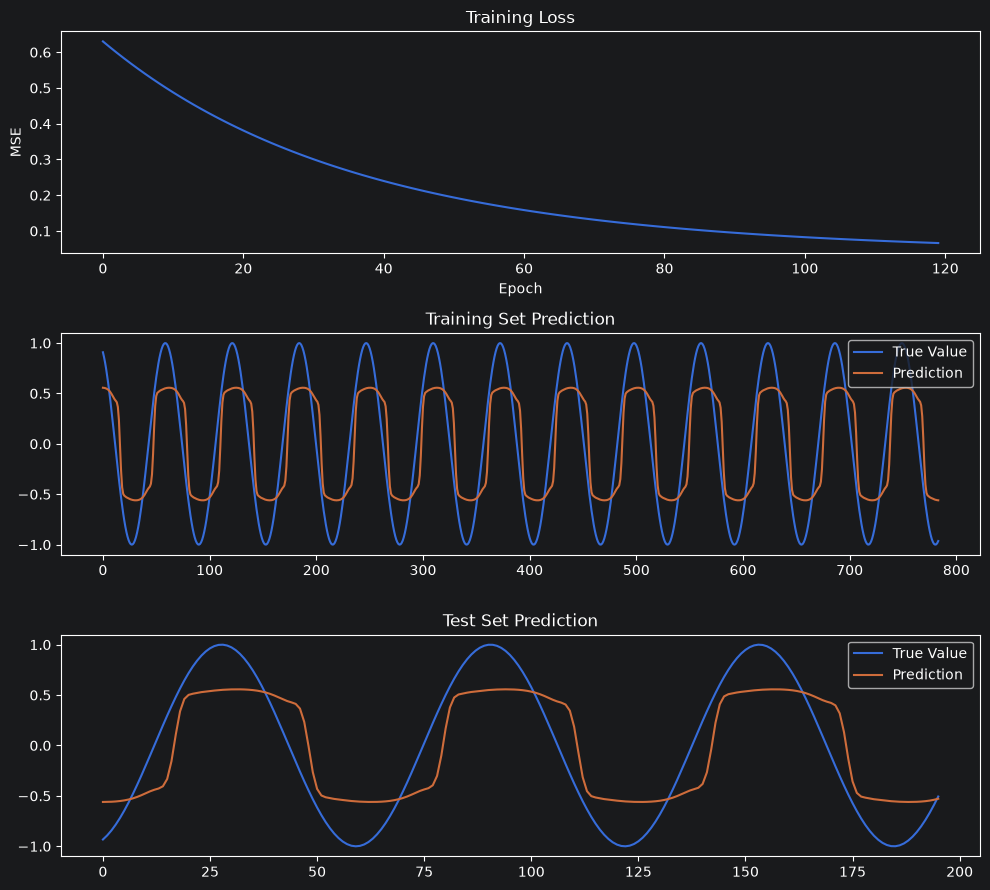

In [5]:
model, loss_history, train_result, test_result = train_rnn()
y_train, train_pred = train_result
y_test, test_pred = test_result

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

axes[0].plot(loss_history)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")

axes[1].plot(y_train, label="True Value")
axes[1].plot(train_pred, label="Prediction")
axes[1].set_title("Training Set Prediction")
axes[1].legend()

axes[2].plot(y_test, label="True Value")
axes[2].plot(test_pred, label="Prediction")
axes[2].set_title("Test Set Prediction")
axes[2].legend()

plt.tight_layout()
plt.show()
